In [138]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split



In [139]:
df = pd.read_csv("loan_approval_data.csv")

In [140]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## Step 1 : Handle missing data

In [141]:
# categorial data -> mode
# numerical data -> mean

categorical_cols = df.select_dtypes(include=["object", "string"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [142]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [143]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

In [144]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])



In [145]:
df.head()
# df.isnull().sum()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Step 2 : EDA - exploratory data analysis

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


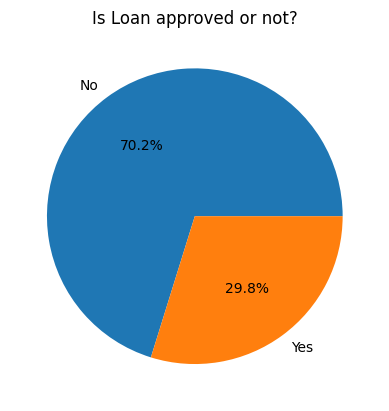

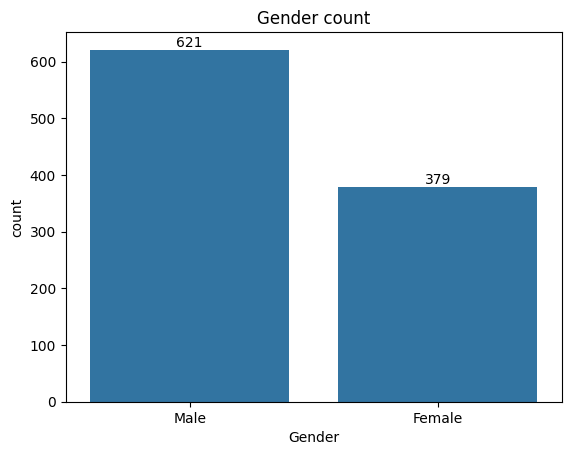

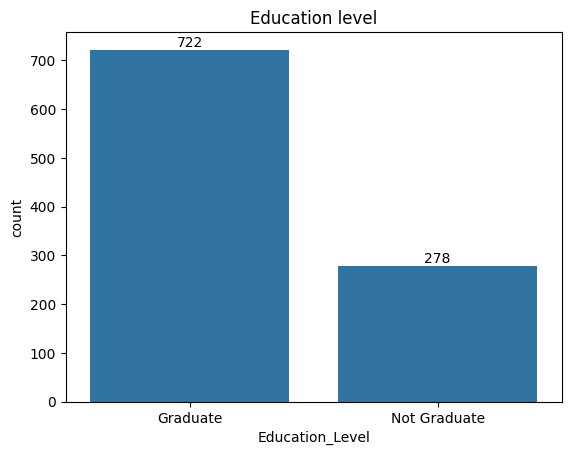

In [146]:
# how balanced our classes are ?

class_count =  df["Loan_Approved"].value_counts()

print(class_count)

plt.pie(class_count, labels=["No","Yes"], autopct="%1.1f%%")        # assign in sequence of value

plt.title("Is Loan approved or not?")
plt.show()





gender_count = df["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])
plt.title("Gender count")
plt.show()


Education = df["Education_Level"].value_counts() 
ax=sns.barplot(Education) 
ax.bar_label(ax.containers[0])
plt.title("Education level")
plt.show()


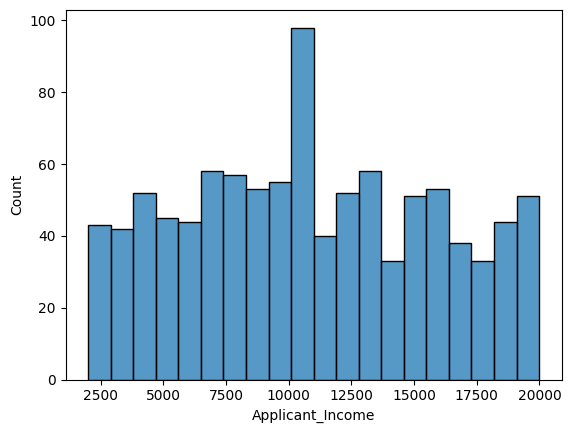

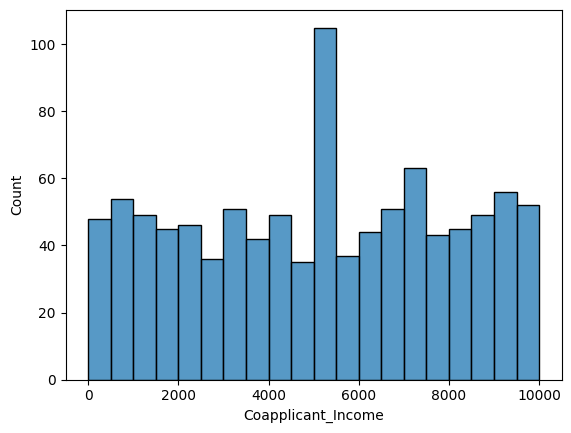

In [147]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income", 
    bins = 20
)
plt.show()



sns.histplot(
    data = df,
    x = "Coapplicant_Income", 
    bins = 20
)
plt.show()




<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

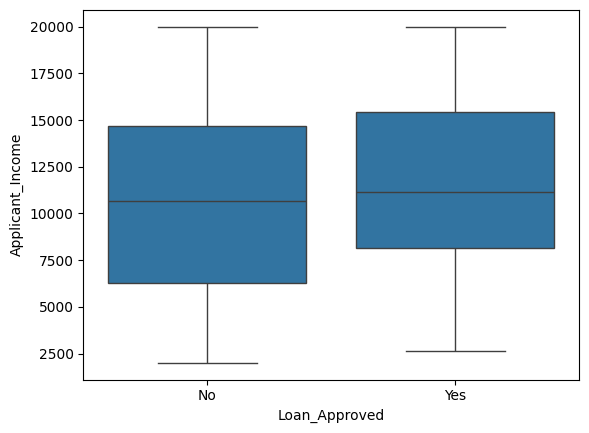

In [148]:
sns.boxplot(
    data=df, 
    x = "Loan_Approved",
    y = "Applicant_Income"
)

# high income has better chance of approval

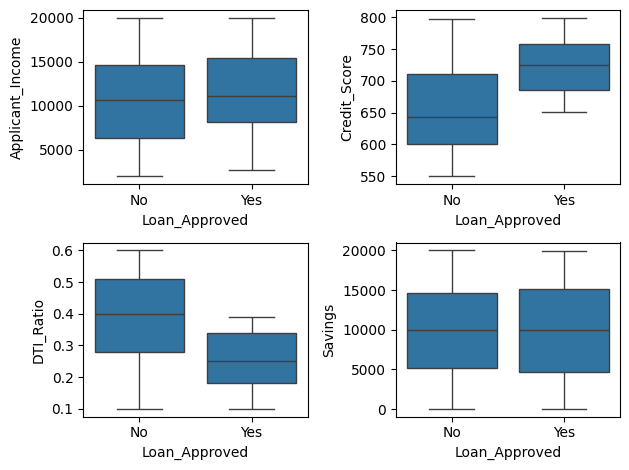

In [151]:
fig, axes = plt. subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes [0, 1], data =df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data =df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data =df, x="Loan_Approved", y="Savings")

plt.tight_layout()